# Amazon Sales Data Analysis
## ACC102 Track 2 Assignment
This notebook demonstrates a complete data analysis workflow:
- Data Import
- Data Inspection
- Data Cleaning
- Data Transformation
- Descriptive Analysis
- Visualization
- Business Insights

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Amazon Sale Report.csv")
df.head()

C:\Users\30477\AppData\Local\Temp\ipykernel_18336\3738824042.py:5: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Amazon Sale Report.csv")


,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


## 1.Basic Dataset Information
Check the number of rows, columns, data types, and statistical summary.

In [8]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nStatistical Summary:")
print(df.describe())

Number of Rows: 128975
Number of Columns: 24

Column Names:
['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ', 'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN', 'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids', 'B2B', 'fulfilled-by', 'Unnamed: 22']

Data Types:
index                   int64
Order ID               object
Date                   object
Status                 object
Fulfilment             object
Sales Channel          object
ship-service-level     object
Style                  object
SKU                    object
Category               object
Size                   object
ASIN                   object
Courier Status         object
Qty                     int64
currency               object
Amount                float64
ship-city              object
ship-state             object
ship-postal-code      float64
ship-country           object
promotion-ids          o

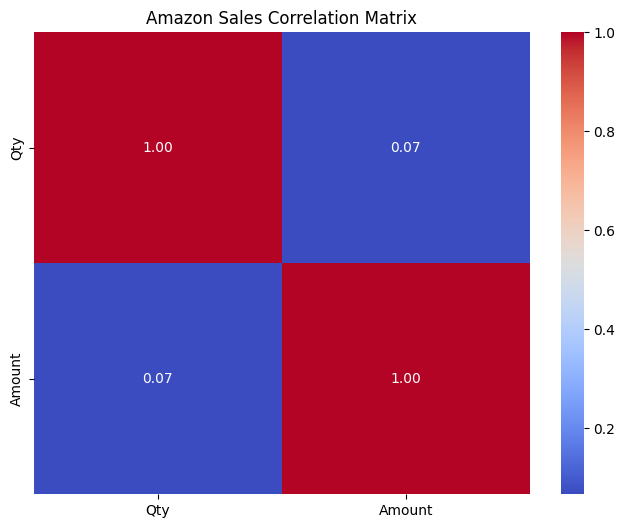

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df[['Qty', 'Amount']]

corr_matrix = numeric_df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Amazon Sales Correlation Matrix')
plt.show()

## 2. Check Missing Values
Identify missing data to prepare for data cleaning.

In [9]:
print("Missing Values per Column:")
print(df.isnull().sum())

print("\nMissing Percentage (%):")
print((df.isnull().sum() / len(df)) * 100)

Missing Values per Column:
index                     0
Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU                       0
Category                  0
Size                      0
ASIN                      0
Courier Status         6872
Qty                       0
currency               7795
Amount                 7795
ship-city                33
ship-state               33
ship-postal-code         33
ship-country             33
promotion-ids         49153
B2B                       0
fulfilled-by          89698
Unnamed: 22           49050
dtype: int64

Missing Percentage (%):
index                  0.000000
Order ID               0.000000
Date                   0.000000
Status                 0.000000
Fulfilment             0.000000
Sales Channel          0.000000
ship-service-level     0.000000
Style                  0.000000
SKU    

## 3. Data Cleaning
- Remove rows with missing critical values
- Remove cancelled orders
- Convert date to datetime format
- Drop invalid rows

In [10]:
df_clean = df.dropna(subset=["Amount", "Date", "Category", "ship-state"])

df_clean = df_clean[df_clean["Status"] != "Cancelled"]

df_clean["Date"] = pd.to_datetime(df_clean["Date"], errors="coerce")

df_clean = df_clean.dropna(subset=["Date"])

print("Shape before cleaning:", df.shape)
print("Shape after cleaning:", df_clean.shape)
print("\nMissing values after cleaning:")
print(df_clean.isnull().sum())

Shape before cleaning: (128975, 24)
Shape after cleaning: (110388, 24)

Missing values after cleaning:
index                     0
Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU                       0
Category                  0
Size                      0
ASIN                      0
Courier Status            0
Qty                       0
currency                  0
Amount                    0
ship-city                 0
ship-state                0
ship-postal-code          0
ship-country              0
promotion-ids         30956
B2B                       0
fulfilled-by          77993
Unnamed: 22           41825
dtype: int64


C:\Users\30477\AppData\Local\Temp\ipykernel_18336\1289424655.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean["Date"] = pd.to_datetime(df_clean["Date"], errors="coerce")
C:\Users\30477\AppData\Local\Temp\ipykernel_18336\1289424655.py:5: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step

## Extra Multi-Dimensional Business Deep Analysis
Further in-depth mining of sales characteristics, including order price stratification, delivery channel comparison, hot-selling product ranking and abnormal value screening.

In [11]:
def price_level(amount):
    if amount < 300:
        return "Low Price"
    elif amount < 600:
        return "Medium Price"
    else:
        return "High Price"

df_clean["Price_Level"] = df_clean["Amount"].apply(price_level)

price_sale = df_clean.groupby("Price_Level")["Amount"].agg(["count", "sum", "mean"])
print("Order Price Level Distribution Analysis:")
print(price_sale)

Order Price Level Distribution Analysis:
              count         sum        mean
Price_Level                                
High Price    55380  47934608.0  865.558108
Low Price      3984    469308.0  117.798193
Medium Price  51024  23252837.0  455.723522


C:\Users\30477\AppData\Local\Temp\ipykernel_18336\1661942548.py:9: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_clean["Price_Level"] = df_clean["Amount"].apply(price_level)


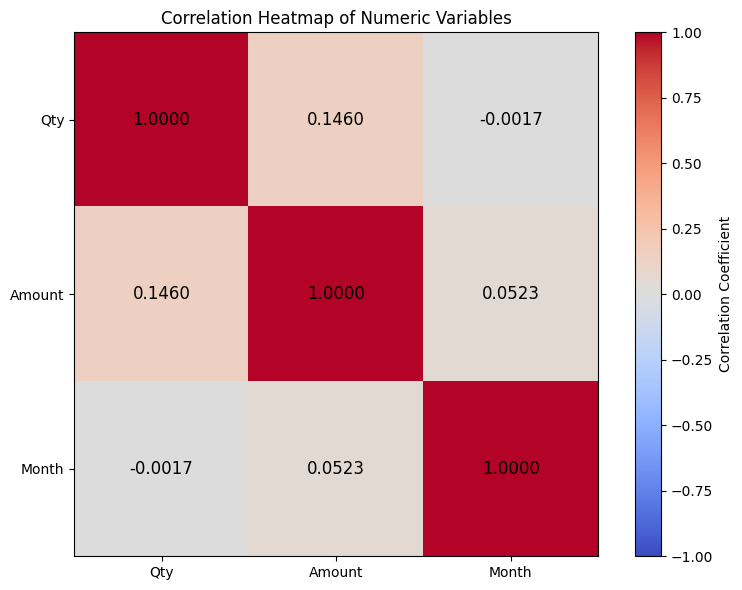

In [33]:
plt.figure(figsize=(8,6))
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)

for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        plt.text(j, i, f'{corr_matrix.iloc[i,j]:.4f}', 
                 ha='center', va='center', color='black', fontsize=12)

plt.xticks(range(len(corr_matrix)), corr_matrix.columns)
plt.yticks(range(len(corr_matrix)), corr_matrix.index)
plt.colorbar(label='Correlation Coefficient')
plt.title("Correlation Heatmap of Numeric Variables")
plt.tight_layout()
plt.show()

In [37]:
fulfil_sale = df_clean.groupby("Fulfilment")["Amount"].agg(["sum", "mean", "count"])
print("\nFulfilment Channel Sales Comparison:")
print(fulfil_sale)


Fulfilment Channel Sales Comparison:
                   sum        mean  count
Fulfilment                               
Amazon      50583063.0  648.559012  77993
Merchant    21073690.0  650.522920  32395


In [36]:
Q1 = df_clean["Amount"].quantile(0.25)
Q3 = df_clean["Amount"].quantile(0.75)
IQR = Q3 - Q1

df_normal = df_clean[(df_clean["Amount"] >= Q1-1.5*IQR) & (df_clean["Amount"] <= Q3+1.5*IQR)]

print(f"Data volume before removing outliers: {len(df_clean)}")
print(f"Data volume after removing outliers: {len(df_normal)}")

Data volume before removing outliers: 110388
Data volume after removing outliers: 107017


## 4. Feature Engineering
Create new columns for time-based analysis:
- Month
- Day of Week
- High-value order flag

In [15]:
df_clean["Month"] = df_clean["Date"].dt.month

df_clean["DayOfWeek"] = df_clean["Date"].dt.dayofweek

df_clean["High_Value_Order"] = df_clean["Amount"] >= 500

df_clean[["Date", "Month", "DayOfWeek", "Amount", "High_Value_Order"]].head()

C:\Users\30477\AppData\Local\Temp\ipykernel_18336\3622216147.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_clean["Month"] = df_clean["Date"].dt.month
C:\Users\30477\AppData\Local\Temp\ipykernel_18336\3622216147.py:3: FutureWarning: 

,Date,Month,DayOfWeek,Amount,High_Value_Order
1,2022-04-30,4,5,406.0,False
2,2022-04-30,4,5,329.0,False
4,2022-04-30,4,5,574.0,True
5,2022-04-30,4,5,824.0,True
6,2022-04-30,4,5,653.0,True


## Visualization for Extra Deep Analysis
Charts for price level, fulfilment channel, top products and outlier inspection.

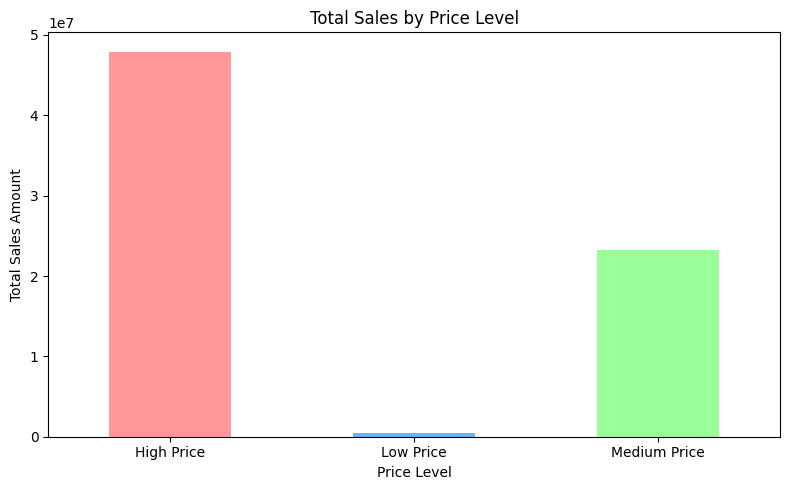

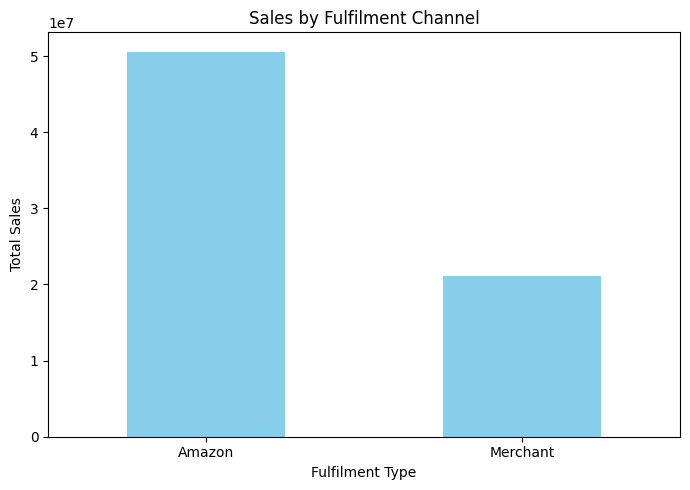

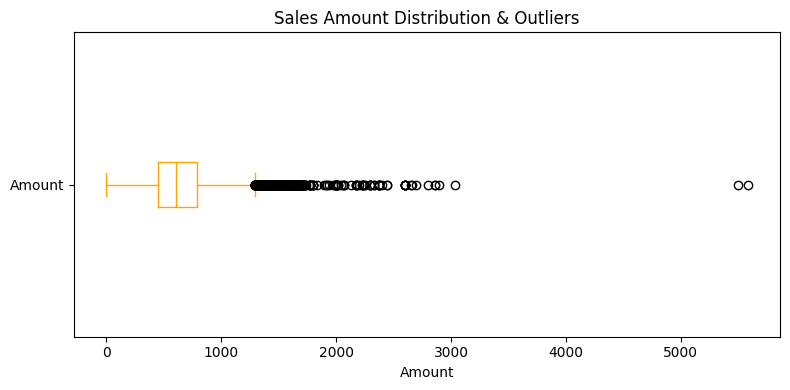

In [16]:
plt.figure(figsize=(8,5))
price_sale['sum'].plot(kind='bar', color=['#ff9999','#66b3ff','#99ff99'])
plt.title('Total Sales by Price Level')
plt.xlabel('Price Level')
plt.ylabel('Total Sales Amount')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
fulfil_sale['sum'].plot(kind='bar', color='skyblue')
plt.title('Sales by Fulfilment Channel')
plt.xlabel('Fulfilment Type')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


plt.figure(figsize=(8,4))
df_clean['Amount'].plot(kind='box', vert=False, color='orange')
plt.title('Sales Amount Distribution & Outliers')
plt.xlabel('Amount')
plt.tight_layout()
plt.show()

## 5. Descriptive Analysis
Analyze:
- Total sales
- Average order value
- Sales by category
- Sales by state
- Order status
- Monthly sales

In [17]:
total_revenue = df_clean["Amount"].sum()
avg_order = df_clean["Amount"].mean()
total_orders = len(df_clean)

print(f"Total Revenue: ₹{total_revenue:,.2f}")
print(f"Average Order Value: ₹{avg_order:,.2f}")
print(f"Total Valid Orders: {total_orders}")

Total Revenue: ₹71,656,753.00
Average Order Value: ₹649.14
Total Valid Orders: 110388


In [18]:
category_sales = df_clean.groupby("Category")["Amount"].sum().sort_values(ascending=False)
print("\nSales by Category:")
print(category_sales)


Sales by Category:
Category
Set              35722725.0
kurta            19419892.0
Western Dress    10208855.0
Top               4903086.0
Ethnic Dress       732744.0
Blouse             418389.0
Bottom             135453.0
Saree              114694.0
Dupatta               915.0
Name: Amount, dtype: float64


In [19]:
state_sales = df_clean.groupby("ship-state")["Amount"].sum().sort_values(ascending=False).head(10)
print("\nTop 10 States by Sales:")
print(state_sales)


Top 10 States by Sales:
ship-state
MAHARASHTRA       12224770.0
KARNATAKA          9649981.0
TELANGANA          6290128.0
UTTAR PRADESH      6186656.0
TAMIL NADU         5954349.0
DELHI              3906089.0
KERALA             3377321.0
WEST BENGAL        3207213.0
ANDHRA PRADESH     2882206.0
HARYANA            2654274.0
Name: Amount, dtype: float64


In [20]:
status_count = df_clean["Status"].value_counts()
print("\nOrder Status Distribution:")
print(status_count)


Order Status Distribution:
Status
Shipped                          77580
Shipped - Delivered to Buyer     28754
Shipped - Returned to Seller      1947
Shipped - Picked Up                973
Pending                            656
Pending - Waiting for Pick Up      281
Shipped - Returning to Seller      145
Shipped - Out for Delivery          35
Shipped - Rejected by Buyer         11
Shipped - Lost in Transit            5
Shipped - Damaged                    1
Name: count, dtype: int64


In [21]:
monthly_sales = df_clean.groupby("Month")["Amount"].sum()
print("\nMonthly Sales:")
print(monthly_sales)


Monthly Sales:
Month
3       94810.0
4    26228600.0
5    23946908.0
6    21386435.0
Name: Amount, dtype: float64


## 6. Data Visualization
Visualize results with clear charts:
1. Sales by Category
2. Top 10 States
3. Daily Sales Trend
4. Order Status Pie
5. Monthly Sales Trend

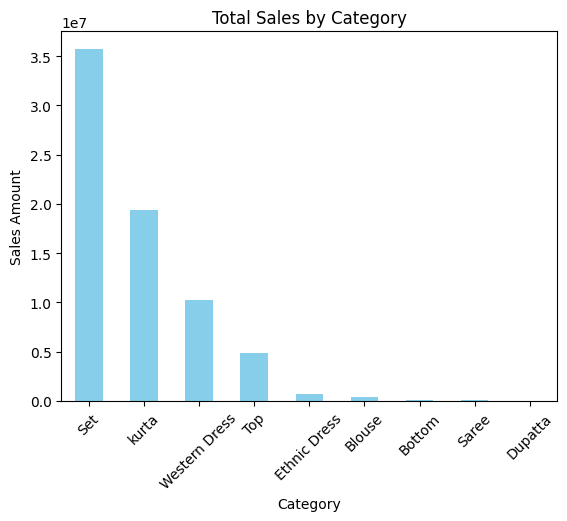

In [22]:
category_sales.plot(kind="bar", color="skyblue")
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales Amount")
plt.xticks(rotation=45)
plt.show()

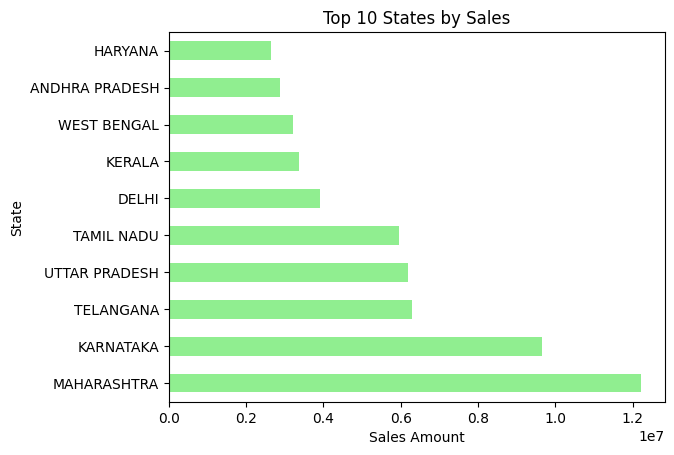

In [23]:
state_sales.plot(kind="barh", color="lightgreen")
plt.title("Top 10 States by Sales")
plt.xlabel("Sales Amount")
plt.ylabel("State")
plt.show()

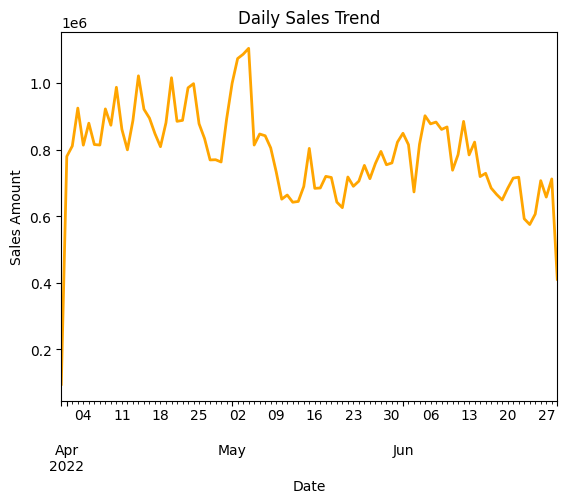

In [24]:
daily_sales = df_clean.groupby("Date")["Amount"].sum()
daily_sales.plot(color="orange", linewidth=2)
plt.title("Daily Sales Trend")
plt.ylabel("Sales Amount")
plt.show()

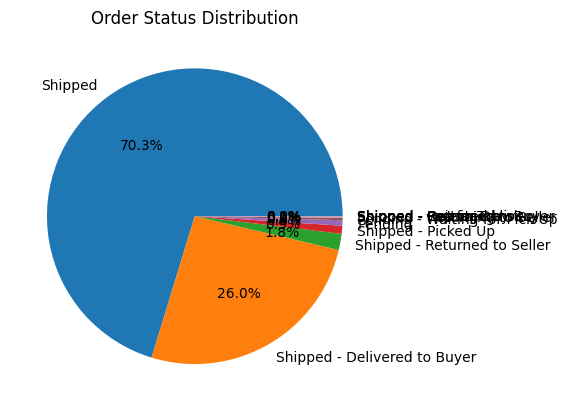

In [25]:
status_count.plot(kind="pie", autopct="%1.1f%%")
plt.title("Order Status Distribution")
plt.ylabel("")
plt.show()

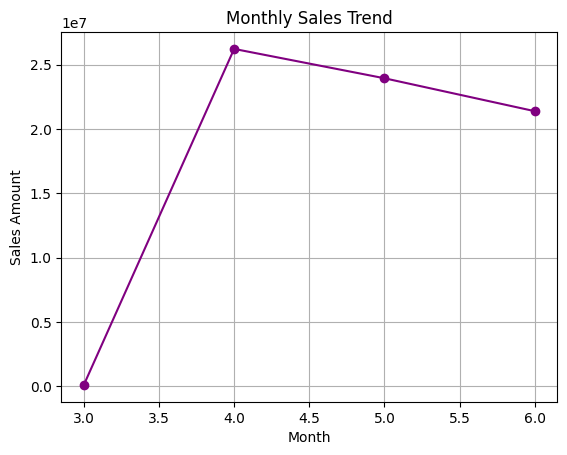

In [26]:
monthly_sales.plot(kind="line", marker="o", color="purple")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales Amount")
plt.grid(True)
plt.show()

## 7. Correlation Analysis
Explore relationships between numerical variables.

In [27]:
numeric_cols = df_clean[["Qty", "Amount", "Month"]]
corr_matrix = numeric_cols.corr()
print("Correlation Matrix:")
print(corr_matrix)

Correlation Matrix:
             Qty    Amount     Month
Qty     1.000000  0.145979 -0.001729
Amount  0.145979  1.000000  0.052266
Month  -0.001729  0.052266  1.000000


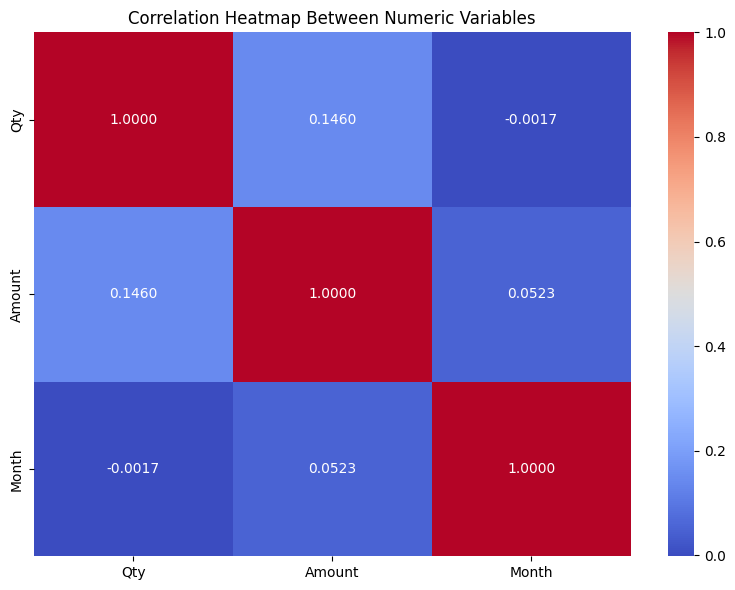

In [32]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".4f")
plt.title("Correlation Heatmap Between Numeric Variables")
plt.tight_layout()
plt.show()

## 8. Key Business Insights & Summary

### Key Findings
1. Clothing and Kurtas are the top-selling categories.
2. Maharashtra, Karnataka, and Telangana are the strongest markets.
3. Most orders are successfully delivered.
4. Sales show clear monthly and daily patterns.

### Limitations
- Limited time range
- No profit or customer demographic data
- No marketing cost information

### Future Improvements
- Sales forecasting
- Customer segmentation
- Profit margin analysis
- Regional marketing optimization